### Import libraries

In [2]:
# ============================================================
# CLASSIFICATION MODEL - STEP 1
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib


print("Libraries imported successfully.")

Libraries imported successfully.


### Load the classification dataset

In [3]:
# ============================================================
# CLASSIFICATION MODEL - STEP 2
# LOAD CLASSIFICATION DATASET
# ============================================================

data_path = "../data/processed/model_data_classification.csv"

df = pd.read_csv(data_path)


print("Classification dataset loaded successfully.")

print("Dataset shape:", df.shape)

display(df.head())

Classification dataset loaded successfully.
Dataset shape: (52930, 83)


,VisitDate,VisitYear,VisitMonth,Rating,UserVisitCount,AttractionVisitCount,VisitMode,Country_Frequency,CityName_Frequency,Continent_Africa,...,Attraction_Sempu Island,Attraction_Sewu Temple,Attraction_Tanah Lot Temple,Attraction_Tegalalang Rice Terrace,Attraction_Tegenungan Waterfall,Attraction_Ullen Sentalu Museum,Attraction_Uluwatu Temple,Attraction_Water Castle (Tamansari),Attraction_Waterbom Bali,Attraction_Yogyakarta Palace
0,2022-10-01,2022,10,5,1,13198,Couples,0.126998,0.000756,0,...,0,0,0,0,0,0,0,0,0,0
1,2022-10-01,2022,10,5,1,13198,Friends,0.028075,0.000208,0,...,0,0,0,0,0,0,0,0,0,0
2,2022-10-01,2022,10,5,1,13198,Family,0.002645,0.000057,0,...,0,0,0,0,0,0,0,0,0,0
3,2022-10-01,2022,10,3,2,13198,Family,0.004893,0.001512,0,...,0,0,0,0,0,0,0,0,0,0
4,2022-10-01,2022,10,3,3,13198,Couples,0.126998,0.003855,0,...,0,0,0,0,0,0,0,0,0,0


### Inspect the dataset

In [4]:
# ============================================================
# CLASSIFICATION MODEL - STEP 3
# BASIC DATASET INSPECTION
# ============================================================

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes.value_counts())

Number of rows: 52930
Number of columns: 83

Column names:
['VisitDate', 'VisitYear', 'VisitMonth', 'Rating', 'UserVisitCount', 'AttractionVisitCount', 'VisitMode', 'Country_Frequency', 'CityName_Frequency', 'Continent_Africa', 'Continent_America', 'Continent_Asia', 'Continent_Australia & Oceania', 'Continent_Europe', 'Region_Australia', 'Region_Caribbean', 'Region_Central Africa', 'Region_Central America', 'Region_Central Asia', 'Region_Central Europe', 'Region_East Africa', 'Region_East Asia', 'Region_Eastern Europe', 'Region_Middle East', 'Region_North Africa', 'Region_Northern America', 'Region_Northern Europe', 'Region_Oceania', 'Region_South America', 'Region_South Asia', 'Region_South East Asia', 'Region_Southern Africa', 'Region_Southern Europe', 'Region_Unknown', 'Region_West Africa', 'Region_Western Europe', 'AttractionType_Ancient Ruins', 'AttractionType_Ballets', 'AttractionType_Beaches', 'AttractionType_Caverns & Caves', 'AttractionType_Flea & Street Markets', 'AttractionT

### Separate features and target

In [5]:
# ============================================================
# CLASSIFICATION MODEL - STEP 4
# SEPARATE FEATURES (X) AND TARGET (y)
# ============================================================

# Target variable
y = df["VisitMode"]


# All other columns are input features
X = df.drop(
    columns=["VisitMode"]
)


print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (52930, 82)
Target shape: (52930,)



### Check the VisitMode classes

In [6]:
# ============================================================
# CLASSIFICATION MODEL - STEP 5
# CHECK TARGET CLASS DISTRIBUTION
# ============================================================

class_counts = y.value_counts()

print("VisitMode class distribution:")
print(class_counts)


print("\nClass percentages:")

class_percentages = (
    y.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentages)

VisitMode class distribution:
VisitMode
Couples     21620
Family      15217
Friends     10945
Solo         4525
Business      623
Name: count, dtype: int64

Class percentages:
VisitMode
Couples     40.85
Family      28.75
Friends     20.68
Solo         8.55
Business     1.18
Name: proportion, dtype: float64


### Prepare the features

In [7]:
# ============================================================
# CLASSIFICATION MODEL - STEP 6
# PREPARE FEATURES FOR MACHINE LEARNING
# ============================================================

# Convert all feature columns to numeric.
# Anything that cannot be converted becomes NaN.
X = X.apply(
    pd.to_numeric,
    errors="coerce"
)


# Replace missing values with zero.
X = X.fillna(0)


# Replace infinite values with zero.
X = X.replace(
    [np.inf, -np.inf],
    0
)


print("Feature preparation completed.")

print(
    "Missing values:",
    X.isnull().sum().sum()
)

print(
    "Infinite values:",
    np.isinf(X.to_numpy()).sum()
)

Feature preparation completed.
Missing values: 0
Infinite values: 0


### Check feature count and memory

In [8]:
# ============================================================
# CLASSIFICATION MODEL - STEP 7
# CHECK FEATURE SIZE AND MEMORY USAGE
# ============================================================

memory_mb = (
    X.memory_usage(deep=True).sum()
    / (1024 ** 2)
)


print(
    f"Feature matrix memory usage: {memory_mb:.2f} MB"
)

print(
    "Number of features:",
    X.shape[1]
)

Feature matrix memory usage: 33.11 MB
Number of features: 82


### Train/Test split

In [9]:
# ============================================================
# CLASSIFICATION MODEL - STEP 8
# TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).round(3))

Training data:
X_train: (42344, 82)
y_train: (42344,)

Testing data:
X_test: (10586, 82)
y_test: (10586,)

Training class distribution:
VisitMode
Couples     0.408
Family      0.288
Friends     0.207
Solo        0.085
Business    0.012
Name: proportion, dtype: float64


### Create a model evaluation function

In [10]:
# ============================================================
# CLASSIFICATION MODEL - STEP 9
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_classification_model(model, X_test, y_test):
    """
    Evaluate a classification model using:

    Accuracy  -> Overall percentage of correct predictions
    Precision -> How many predicted classes were correct
    Recall    -> How many actual classes were found
    F1        -> Balance between precision and recall

    Macro averaging gives equal importance to every class.
    """

    # Generate predictions
    predictions = model.predict(X_test)


    # Accuracy
    accuracy = accuracy_score(
        y_test,
        predictions
    )


    # Macro precision
    precision = precision_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )


    # Macro recall
    recall = recall_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )


    # Macro F1
    f1 = f1_score(
        y_test,
        predictions,
        average="macro",
        zero_division=0
    )


    return accuracy, precision, recall, f1

### Train Logistic Regression

In [11]:
# ============================================================
# CLASSIFICATION MODEL - STEP 10
# LOGISTIC REGRESSION BASELINE
# ============================================================

logistic_model = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)


print("Training Logistic Regression...")

logistic_model.fit(
    X_train,
    y_train
)


print("Logistic Regression training completed.")

Training Logistic Regression...
Logistic Regression training completed.


### Evaluate Logistic Regression

In [12]:
# ============================================================
# CLASSIFICATION MODEL - STEP 11
# EVALUATE LOGISTIC REGRESSION
# ============================================================

(
    logistic_accuracy,
    logistic_precision,
    logistic_recall,
    logistic_f1
) = evaluate_classification_model(
    logistic_model,
    X_test,
    y_test
)


print("Logistic Regression Results")
print("---------------------------")

print(
    f"Accuracy  : {logistic_accuracy:.4f}"
)

print(
    f"Precision : {logistic_precision:.4f}"
)

print(
    f"Recall    : {logistic_recall:.4f}"
)

print(
    f"F1 Score  : {logistic_f1:.4f}"
)

Logistic Regression Results
---------------------------
Accuracy  : 0.3200
Precision : 0.2915
Recall    : 0.3509
F1 Score  : 0.2466


### Train Random Forest

In [13]:
# ============================================================
# CLASSIFICATION MODEL - STEP 12
# RANDOM FOREST CLASSIFIER
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


print("Training Random Forest...")

random_forest.fit(
    X_train,
    y_train
)


print("Random Forest training completed.")

Training Random Forest...
Random Forest training completed.


### Evaluate Random Forest

In [14]:
# ============================================================
# CLASSIFICATION MODEL - STEP 13
# EVALUATE RANDOM FOREST
# ============================================================

(
    rf_accuracy,
    rf_precision,
    rf_recall,
    rf_f1
) = evaluate_classification_model(
    random_forest,
    X_test,
    y_test
)


print("Random Forest Results")
print("---------------------")

print(
    f"Accuracy  : {rf_accuracy:.4f}"
)

print(
    f"Precision : {rf_precision:.4f}"
)

print(
    f"Recall    : {rf_recall:.4f}"
)

print(
    f"F1 Score  : {rf_f1:.4f}"
)

Random Forest Results
---------------------
Accuracy  : 0.4015
Precision : 0.3323
Recall    : 0.4064
F1 Score  : 0.3190


### Check XGBoost

In [15]:
# ============================================================
# CLASSIFICATION MODEL - STEP 14
# CHECK XGBOOST
# ============================================================

try:

    import xgboost as xgb

    print(
        "XGBoost is installed."
    )

    print(
        "Version:",
        xgb.__version__
    )

    xgboost_available = True

except ImportError:

    print(
        "XGBoost is not installed."
    )

    xgboost_available = False

XGBoost is installed.
Version: 3.4.1


### Train XGBoost Classifier

In [16]:
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

# Convert VisitMode text labels into numbers
# Business -> 0
# Couples  -> 1
# Family   -> 2
# Friends  -> 3
# Solo     -> 4

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)
y_test_xgb = label_encoder.transform(y_test)

print("XGBoost class mapping:")
for number, label in enumerate(label_encoder.classes_):
    print(number, "=", label)


# Create XGBoost model
xgboost_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1
)

print("Training XGBoost...")

xgboost_model.fit(
    X_train,
    y_train_xgb
)

print("XGBoost training completed!")

XGBoost class mapping:
0 = Business
1 = Couples
2 = Family
3 = Friends
4 = Solo
Training XGBoost...
XGBoost training completed!


### Evaluate XGBoost

In [17]:
# Make XGBoost predictions
xgb_predictions = xgboost_model.predict(X_test)

# Convert XGBoost numeric predictions back to the original text labels
xgb_predictions_labels = label_encoder.inverse_transform(
    xgb_predictions.astype(int)
)

# Calculate metrics using the original text labels
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions_labels
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions_labels,
    average="macro",
    zero_division=0
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions_labels,
    average="macro",
    zero_division=0
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions_labels,
    average="macro",
    zero_division=0
)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))

XGBoost Results
----------------
Accuracy : 0.4823
Precision: 0.431
Recall   : 0.2743
F1 Score : 0.2576


In [18]:
# ============================================================
# CLASSIFICATION MODEL - STEP 17
# MODEL COMPARISON
# ============================================================

results = [
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1": logistic_f1
    },
    {
        "Model": "Random Forest",
        "Accuracy": rf_accuracy,
        "Precision": rf_precision,
        "Recall": rf_recall,
        "F1": rf_f1
    }
]


# Add XGBoost if available
if xgboost_available:

    results.append(
        {
            "Model": "XGBoost",
            "Accuracy": xgb_accuracy,
            "Precision": xgb_precision,
            "Recall": xgb_recall,
            "F1": xgb_f1
        }
    )


comparison_df = pd.DataFrame(results)


# Sort models by macro F1 score
comparison_df = (
    comparison_df
    .sort_values(
        by="F1",
        ascending=False
    )
    .reset_index(drop=True)
)


display(comparison_df)

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.401474,0.332290,0.406376,0.319018
1,XGBoost,0.482335,0.431025,0.274339,0.257562
2,Logistic Regression,0.320045,0.291473,0.350922,0.246641


### Identify the best model

In [19]:
# ============================================================
# CLASSIFICATION MODEL - STEP 18
# SELECT BEST MODEL
# ============================================================

best_model_name = comparison_df.iloc[0]["Model"]


print(
    "Best model based on macro F1:",
    best_model_name
)

Best model based on macro F1: Random Forest


### Select the actual model object

In [20]:
# ============================================================
# CLASSIFICATION MODEL - STEP 19
# GET BEST MODEL OBJECT
# ============================================================

if best_model_name == "Logistic Regression":

    best_model = logistic_model

elif best_model_name == "Random Forest":

    best_model = random_forest

elif best_model_name == "XGBoost":

    best_model = xgboost_model


print(
    "Selected model:",
    type(best_model).__name__
)

Selected model: RandomForestClassifier


#### Generate detailed classification report

In [21]:
# ============================================================
# CLASSIFICATION MODEL - STEP 20
# DETAILED CLASSIFICATION REPORT
# ============================================================

best_predictions = best_model.predict(
    X_test
)


print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Business       0.06      0.57      0.11       125
     Couples       0.53      0.51      0.52      4324
      Family       0.54      0.37      0.44      3043
     Friends       0.34      0.24      0.28      2189
        Solo       0.18      0.34      0.24       905

    accuracy                           0.40     10586
   macro avg       0.33      0.41      0.32     10586
weighted avg       0.46      0.40      0.42     10586



### Create the confusion matrix

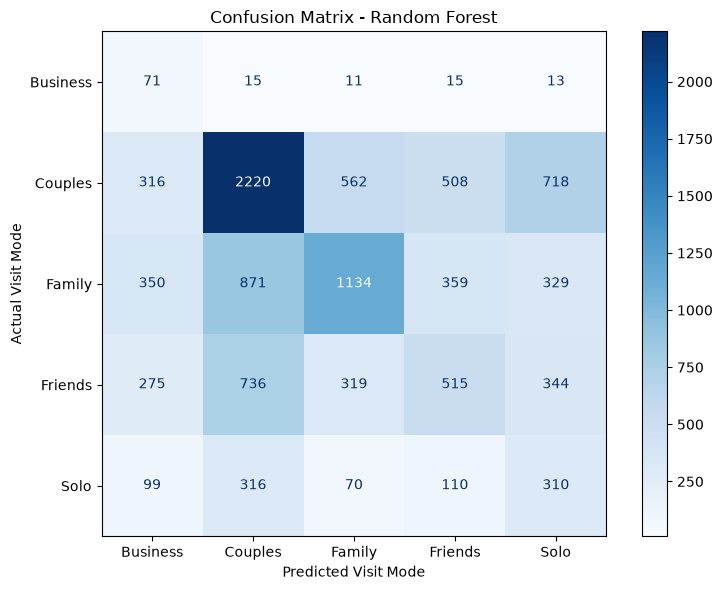

Confusion matrix saved:
../charts/classification_confusion_matrix.png


In [22]:
# ============================================================
# CLASSIFICATION MODEL - STEP 21
# CONFUSION MATRIX
# ============================================================

# Get the unique class labels
class_labels = sorted(
    y_test.unique()
)


# Calculate confusion matrix
cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=class_labels
)


# Create the plot
fig, ax = plt.subplots(
    figsize=(8, 6)
)


display_labels = [
    str(label)
    for label in class_labels
]


disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)


disp.plot(
    ax=ax,
    values_format="d",
    cmap="Blues"
)


plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel(
    "Predicted Visit Mode"
)

plt.ylabel(
    "Actual Visit Mode"
)

plt.tight_layout()


# Create charts directory
Path("../charts").mkdir(
    parents=True,
    exist_ok=True
)


# Save confusion matrix
confusion_matrix_path = (
    "../charts/classification_confusion_matrix.png"
)


plt.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight"
)


plt.show()


print(
    "Confusion matrix saved:"
)

print(
    confusion_matrix_path
)

### Save the metrics comparison table

In [23]:
# ============================================================
# CLASSIFICATION MODEL - STEP 22
# SAVE METRICS COMPARISON TABLE
# ============================================================

metrics_path = (
    "../data/classification_model_comparison.csv"
)


comparison_df.to_csv(
    metrics_path,
    index=False
)


print(
    "Classification metrics table saved successfully."
)

print(
    "File:",
    metrics_path
)

Classification metrics table saved successfully.
File: ../data/classification_model_comparison.csv


### create the models folder

In [24]:
# ============================================================
# CLASSIFICATION MODEL - STEP 23
# CREATE MODELS DIRECTORY
# ============================================================

models_dir = Path(
    "../models"
)


models_dir.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Models directory ready."
)

Models directory ready.


#### Save the best classification model

In [25]:
# ============================================================
# CLASSIFICATION MODEL - STEP 24
# SAVE BEST CLASSIFICATION MODEL
# ============================================================

classification_model_path = (
    models_dir /
    "classification_model.pkl"
)


joblib.dump(
    best_model,
    classification_model_path
)


print(
    "Best classification model saved successfully!"
)

print(
    "Model path:",
    classification_model_path
)

Best classification model saved successfully!
Model path: ../models/classification_model.pkl


#### Verify the model

In [26]:
# ============================================================
# CLASSIFICATION MODEL - STEP 25
# VERIFY SAVED MODEL
# ============================================================

print(
    "Classification model exists:",
    classification_model_path.exists()
)


if classification_model_path.exists():

    model_size_kb = (
        classification_model_path.stat().st_size
        / 1024
    )

    print(
        f"Model size: {model_size_kb:.2f} KB"
    )

Classification model exists: True
Model size: 41908.69 KB


#### Load the saved model

In [27]:
# ============================================================
# CLASSIFICATION MODEL - STEP 26
# LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    classification_model_path
)


print(
    "Saved classification model loaded successfully."
)

print(
    "Loaded model type:",
    type(loaded_model).__name__
)

Saved classification model loaded successfully.
Loaded model type: RandomForestClassifier


### Test the saved Model

In [28]:
# ============================================================
# CLASSIFICATION MODEL - STEP 27
# TEST SAVED MODEL
# ============================================================

sample_X = X_test.iloc[:5]

sample_y = y_test.iloc[:5]


sample_predictions = (
    loaded_model.predict(sample_X)
)


sample_results = pd.DataFrame(
    {
        "Actual_VisitMode": sample_y.values,
        "Predicted_VisitMode": sample_predictions
    }
)


display(sample_results)

,Actual_VisitMode,Predicted_VisitMode
0,Friends,Family
1,Family,Family
2,Friends,Couples
3,Couples,Couples
4,Solo,Solo


#### Save detailed classification report

In [29]:
# ============================================================
# CLASSIFICATION MODEL - STEP 28
# SAVE DETAILED CLASSIFICATION REPORT
# ============================================================

report = classification_report(
    y_test,
    best_predictions,
    zero_division=0
)


report_path = (
    "../data/classification_report.txt"
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(report)


print(
    "Classification report saved:"
)

print(
    report_path
)

Classification report saved:
../data/classification_report.txt


In [30]:
# -----------------------------------------
# Check classification model features
# -----------------------------------------

classification_model = joblib.load(
    "../models/classification_model.pkl"
)

print(
    "Classification model type:",
    type(classification_model)
)

# Check whether the model exposes feature names
if hasattr(
    classification_model,
    "feature_names_in_"
):

    print(
        "Number of expected features:",
        len(classification_model.feature_names_in_)
    )

    print(
        classification_model.feature_names_in_
    )

else:

    print(
        "Feature names are not directly available."
    )

Classification model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Number of expected features: 82
['VisitDate' 'VisitYear' 'VisitMonth' 'Rating' 'UserVisitCount'
 'AttractionVisitCount' 'Country_Frequency' 'CityName_Frequency'
 'Continent_Africa' 'Continent_America' 'Continent_Asia'
 'Continent_Australia & Oceania' 'Continent_Europe' 'Region_Australia'
 'Region_Caribbean' 'Region_Central Africa' 'Region_Central America'
 'Region_Central Asia' 'Region_Central Europe' 'Region_East Africa'
 'Region_East Asia' 'Region_Eastern Europe' 'Region_Middle East'
 'Region_North Africa' 'Region_Northern America' 'Region_Northern Europe'
 'Region_Oceania' 'Region_South America' 'Region_South Asia'
 'Region_South East Asia' 'Region_Southern Africa'
 'Region_Southern Europe' 'Region_Unknown' 'Region_West Africa'
 'Region_Western Europe' 'AttractionType_Ancient Ruins'
 'AttractionType_Ballets' 'AttractionType_Beaches'
 'AttractionType_Caverns & Caves' 'AttractionType_Flea & Street Mar